In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

#### Load Data

In [3]:
data_path = "dataset"

In [4]:
train_transforms_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
val_test_transforms_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
full_train_dataset = datasets.ImageFolder(
    root=data_path,
    transform=train_transforms_tl
)

In [7]:
full_val_test_dataset = datasets.ImageFolder(
    root=data_path,
    transform=val_test_transforms_tl
)

In [9]:
num_classes=len(full_train_dataset.classes)
num_classes

16

In [10]:
full_train_dataset.classes

['F_Banana',
 'F_Lemon',
 'F_Lulo',
 'F_Mango',
 'F_Orange',
 'F_Strawberry',
 'F_Tamarillo',
 'F_Tomato',
 'S_Banana',
 'S_Lemon',
 'S_Lulo',
 'S_Mango',
 'S_Orange',
 'S_Strawberry',
 'S_Tamarillo',
 'S_Tomato']

In [12]:
total_size = len(full_train_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_size,test_size,val_size

(11200, 2400, 2400)

In [16]:
from torch.utils.data import DataLoader,random_split

In [18]:
train_dataset, val_dataset, test_dataset = random_split(full_train_dataset,[train_size, val_size, test_size],generator=torch.Generator().manual_seed(42))

#### Create DataLoaders

In [20]:
batch_size = 64

In [21]:
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

In [22]:
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

#### Load pretrained ResNet50

In [24]:
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

In [25]:
#### Freeze the pretrained layers
for param in model_resnet50.parameters():
    param.requires_grad = False

In [26]:
#### Replace the final layer
print(model_resnet50.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [27]:
model_resnet50.fc = nn.Linear(model_resnet50.fc.in_features,16)

In [28]:
model_resnet50 = model_resnet50.to(device)

In [29]:
criterion_resnet50 = nn.CrossEntropyLoss()

optimizer_resnet50 = optim.Adam(
    model_resnet50.fc.parameters(),
    lr=0.001
)

#### Train ResNet50

In [30]:
import time

def train_model(model, criterion, optimizer, epochs=5):

    start = time.time()

    epoch_log = []
    
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        train_correct = 0
        train_total = 0

        for batch_num, (images, labels) in enumerate(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Update weights
            optimizer.step()

            # Add batch loss
            running_loss += loss.item() * images.size(0)

            _,predicted=torch.max(outputs,1)
            train_total+=labels.size(0)
            train_correct += (predicted == labels).sum().item()

            # Print every 10 batches
            if (batch_num + 1) % 10 == 0:

                print(
                    f"Epoch: {epoch+1}, "
                    f"Batch: {batch_num+1}, "
                    f"Loss: {loss.item():.4f}"
                )

        # =====================
        # Average Training Loss
        # =====================

        epoch_loss = running_loss / len(train_loader.dataset)
        train_accuracy = 100 * train_correct / train_total

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Training Loss: {epoch_loss:.4f}"
        )
        print(
            f"Training Accuracy: {train_accuracy:.2f}%"
        )

        # =====================
        # Validation
        # =====================

        model.eval()

        correct = 0
        total = 0

        all_labels = []
        all_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Get predicted class
                _, predicted = torch.max(outputs, 1)

                # Count total images
                total += labels.size(0)

                # Count correct predictions
                correct += (predicted == labels).sum().item()

                # Store actual and predicted labels
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        # Calculate validation accuracy
        validation_accuracy = 100 * correct / total

        print(
            f"*** Validation Accuracy: "
            f"{validation_accuracy:.2f}% ***"
        )
        # Save Epoch Log
        epoch_log.append({
            "Epoch": epoch + 1,
            "Training Loss": epoch_loss,
            "Training Accuracy": train_accuracy,
            "Validation Accuracy": validation_accuracy
        })
        

    # =====================
    # Execution Time
    # =====================

    end = time.time()

    print(
        f"\nExecution time: "
        f"{end - start:.2f} seconds"
    )

    return epoch_log,all_labels, all_predictions

#### Experiment-1 : 3 epochs

In [42]:
epoch_log_3, labels_3, predictions_3 = train_model(
    model_resnet50,
    criterion_resnet50,
    optimizer_resnet50,
    epochs=3
)

Epoch: 1, Batch: 10, Loss: 0.0204
Epoch: 1, Batch: 20, Loss: 0.0381
Epoch: 1, Batch: 30, Loss: 0.0553
Epoch: 1, Batch: 40, Loss: 0.0228
Epoch: 1, Batch: 50, Loss: 0.0354
Epoch: 1, Batch: 60, Loss: 0.0141
Epoch: 1, Batch: 70, Loss: 0.0208
Epoch: 1, Batch: 80, Loss: 0.0332
Epoch: 1, Batch: 90, Loss: 0.0237
Epoch: 1, Batch: 100, Loss: 0.0235
Epoch: 1, Batch: 110, Loss: 0.0256
Epoch: 1, Batch: 120, Loss: 0.0169
Epoch: 1, Batch: 130, Loss: 0.0296
Epoch: 1, Batch: 140, Loss: 0.0187
Epoch: 1, Batch: 150, Loss: 0.0345
Epoch: 1, Batch: 160, Loss: 0.0206
Epoch: 1, Batch: 170, Loss: 0.0226
Epoch [1/3], Training Loss: 0.0294
Training Accuracy: 99.67%
*** Validation Accuracy: 99.75% ***
Epoch: 2, Batch: 10, Loss: 0.0560
Epoch: 2, Batch: 20, Loss: 0.0222
Epoch: 2, Batch: 30, Loss: 0.0172
Epoch: 2, Batch: 40, Loss: 0.0314
Epoch: 2, Batch: 50, Loss: 0.0664
Epoch: 2, Batch: 60, Loss: 0.0219
Epoch: 2, Batch: 70, Loss: 0.0151
Epoch: 2, Batch: 80, Loss: 0.0811
Epoch: 2, Batch: 90, Loss: 0.0374
Epoch: 2, B

#### Save the Model

In [43]:
torch.save({"model_state_dict": model_resnet50.state_dict()}, "best_resnet50_freshharvest.pth")
print("Model saved successfully!")

Model saved successfully!


#### Experiment-1 : 5 epochs

In [32]:
log_resnet50 = train_model(
    model_resnet50,
    criterion_resnet50,
    optimizer_resnet50,
    epochs=5
)

Epoch: 1, Batch: 10, Loss: 0.1052
Epoch: 1, Batch: 20, Loss: 0.0976
Epoch: 1, Batch: 30, Loss: 0.0890
Epoch: 1, Batch: 40, Loss: 0.1078
Epoch: 1, Batch: 50, Loss: 0.0993
Epoch: 1, Batch: 60, Loss: 0.1409
Epoch: 1, Batch: 70, Loss: 0.0673
Epoch: 1, Batch: 80, Loss: 0.1131
Epoch: 1, Batch: 90, Loss: 0.1171
Epoch: 1, Batch: 100, Loss: 0.0611
Epoch: 1, Batch: 110, Loss: 0.0745
Epoch: 1, Batch: 120, Loss: 0.0965
Epoch: 1, Batch: 130, Loss: 0.0893
Epoch: 1, Batch: 140, Loss: 0.0965
Epoch: 1, Batch: 150, Loss: 0.0722
Epoch: 1, Batch: 160, Loss: 0.0648
Epoch: 1, Batch: 170, Loss: 0.0948
Epoch [1/5], Training Loss: 0.1016
Training Accuracy: 99.29%
*** Validation Accuracy: 99.29% ***
Epoch: 2, Batch: 10, Loss: 0.0963
Epoch: 2, Batch: 20, Loss: 0.0882
Epoch: 2, Batch: 30, Loss: 0.1022
Epoch: 2, Batch: 40, Loss: 0.0762
Epoch: 2, Batch: 50, Loss: 0.1005
Epoch: 2, Batch: 60, Loss: 0.0607
Epoch: 2, Batch: 70, Loss: 0.1109
Epoch: 2, Batch: 80, Loss: 0.0735
Epoch: 2, Batch: 90, Loss: 0.0756
Epoch: 2, B

The model achieved its best validation accuracy of 99.62% at Epoch 3, with a training accuracy of 99.81%. The very small difference between training and validation accuracy indicates good generalization with minimal overfitting. Further training up to Epoch 5 did not improve validation performance, suggesting that Epoch 3 was sufficient.

In [45]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the saved model
checkpoint = torch.load(
    "best_resnet50_freshharvest.pth",
    map_location=device
)

model_resnet50.load_state_dict(checkpoint["model_state_dict"])

model_resnet50 = model_resnet50.to(device)
model_resnet50.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_resnet50(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Calculate metrics
test_accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_predictions, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Recall        : {recall * 100:.2f}%")
print(f"F1 Score      : {f1 * 100:.2f}%")

Test Accuracy : 99.58%
Precision     : 99.59%
Recall        : 99.58%
F1 Score      : 99.58%


In [46]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[122   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 154   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 160   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 161   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 153   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 147   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 163   0   0   0   0   0   0   0   1   0]
 [  0   0   0   0   0   0   0 143   0   0   0   0   0   0   0   1]
 [  0   0   0   0   0   0   0   0 146   0   0   0   0   0   0   0]
 [  0   4   0   0   0   0   0   0   0 147   0   0   0   0   0   0]
 [  0   0   2   1   0   0   0   0   0   0 167   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 140   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   1 136   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 159   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 146 

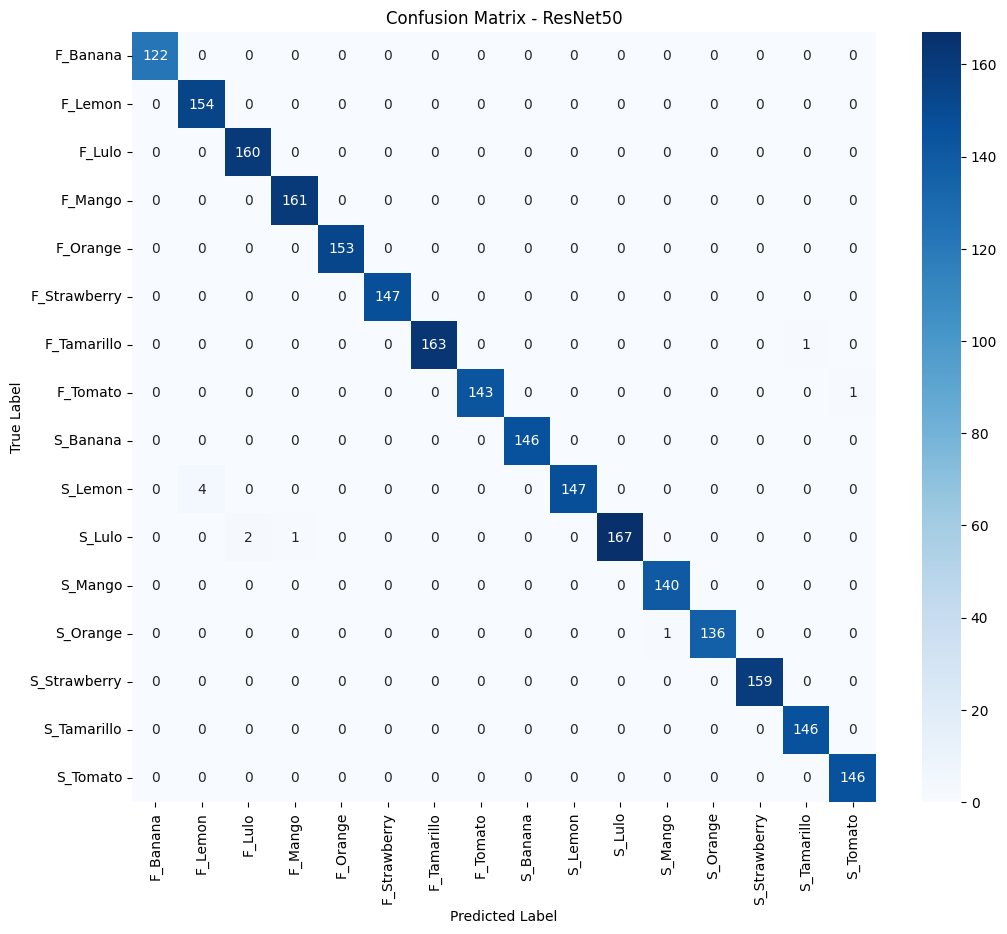

In [50]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.dataset.classes,
    yticklabels=test_dataset.dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50")
plt.savefig(
    "resnet50_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()